In [1]:
from openmm.app import *
from openmm import *
from openmm.unit import *
from sys import stdout
from openmmtools.integrators import LangevinIntegrator, LangevinSplittingGirsanov
import matplotlib

import numpy as np
from matplotlib import pyplot as plt

import gc

from scipy.interpolate import CubicSpline
from potential import *

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



In [2]:
##############################################################################
# Global parameters
##############################################################################
mass = 1.0 * dalton
temp = 298.15
temperature = temp * kelvin
collision_rate = 10 / picosecond
timestep = 5 * femtosecond
splitting = 'R V O V R'
nstxout = 20
kt = temp*8.314/1000
platform = Platform.getPlatformByName('CUDA')

In [3]:
# matplotlib fonts
# matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 20

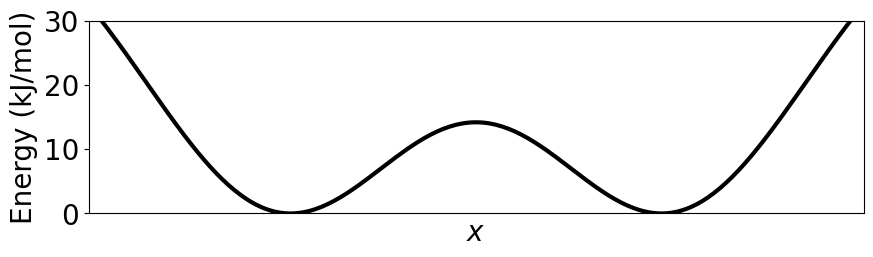

In [5]:
fig,ax = plt.subplots(figsize=(10,2.5))
DoubleWellForce().plot(ax=ax,linewidth=3,color='black')
ax.tick_params(bottom=False, labelbottom=False)
ax.set_ylim(0,30)
ax.set_xlim(-1,1)
ax.set_xlabel('$x$')
ax.set_ylabel('Energy (kJ/mol)')
plt.savefig('figures/1d_doublewell/energy.png',dpi=600)

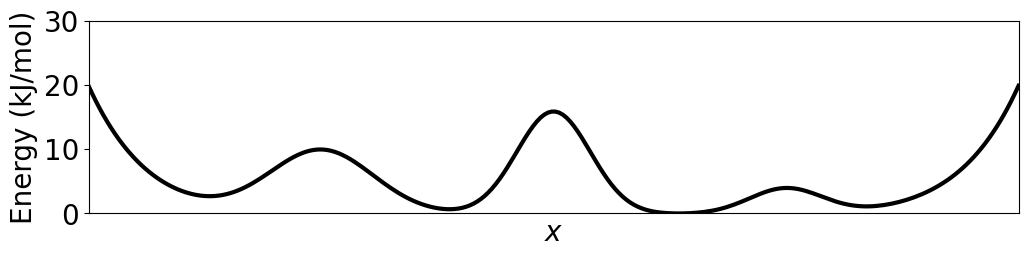

In [6]:
fig,ax = plt.subplots(figsize=(12,2.5))
QuadraWellForce().plot(ax=ax,linewidth=3,color='black')
ax.tick_params(bottom=False, labelbottom=False)
ax.set_ylim(0,30)
ax.set_xlim(-1,1)
ax.set_xlabel('$x$')
ax.set_ylabel('Energy (kJ/mol)')
plt.savefig('figures/1d_quadrawell/energy.png',dpi=600)

#### 0. Unbiased Simulation as Reference

##### 0.1 1D doublewell potential

In [44]:
# Simulation setup
n_sim = 10
n_iters = 1000000

# Run 1D doublewell simulation
system = System()
systemforce = DoubleWellForce()
starting_positions = np.concatenate(
    [np.tile([-0.5,0,0],(int(n_sim/2),1)),np.tile([0.5,0,0],(int(n_sim/2),1))],axis=0
)

# For unbiased simulation, we can parallelize the independent runs.
for n in range(n_sim):
    system.addParticle(mass)
    systemforce.addParticle(n, [])
system.addForce(systemforce)

topology = app.Topology()

# Langevin integrator that allows girsanov reweighting factor output
integrator = LangevinSplittingGirsanov(
    nstxout = nstxout, temperature = temperature,collision_rate = collision_rate,
    timestep = timestep, splitting = splitting
)

# Create simulation
simulation = Simulation(topology,system,integrator,platform)
simulation.context.setPositions(starting_positions)
simulation.context.setVelocitiesToTemperature(temperature)

In [45]:
%%time
save_dir = 'traj_and_dat/1d_doublewell/unbiased_{n_sim}x{n_iters}.npy'.format(
    n_sim = n_sim, n_iters = n_iters
)

data = np.zeros((n_sim,n_iters))
for j in range(n_iters):
    if j % 1000 == 0:
        print(str(j)+'/'+str(n_iters))
    data[:,j] = simulation.context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(nanometer)[:,0]
    simulation.step(nstxout)

np.save(save_dir,data)

0/1000000
1000/1000000
2000/1000000
3000/1000000
4000/1000000
5000/1000000
6000/1000000
7000/1000000
8000/1000000
9000/1000000
10000/1000000
11000/1000000
12000/1000000
13000/1000000
14000/1000000
15000/1000000
16000/1000000
17000/1000000
18000/1000000
19000/1000000
20000/1000000
21000/1000000
22000/1000000
23000/1000000
24000/1000000
25000/1000000
26000/1000000
27000/1000000
28000/1000000
29000/1000000
30000/1000000
31000/1000000
32000/1000000
33000/1000000
34000/1000000
35000/1000000
36000/1000000
37000/1000000
38000/1000000
39000/1000000
40000/1000000
41000/1000000
42000/1000000
43000/1000000
44000/1000000
45000/1000000
46000/1000000
47000/1000000
48000/1000000
49000/1000000
50000/1000000
51000/1000000
52000/1000000
53000/1000000
54000/1000000
55000/1000000
56000/1000000
57000/1000000
58000/1000000
59000/1000000
60000/1000000
61000/1000000
62000/1000000
63000/1000000
64000/1000000
65000/1000000
66000/1000000
67000/1000000
68000/1000000
69000/1000000
70000/1000000
71000/1000000
72000

##### 0.2 1D Quadrawell Potential

In [46]:
# Simulation setup
n_sim = 10
n_iters = 1000000

# Run 1D quadrawell simulation
system = System()
systemforce = QuadraWellForce()
starting_positions = np.concatenate(
    [np.tile([-0.75,0,0],(int(n_sim/2),1)),
     np.tile([0.75,0,0],(int(n_sim/2),1)),],axis=0
)

# For unbiased simulation, we can parallelize the independent runs.
for n in range(n_sim):
    system.addParticle(mass)
    systemforce.addParticle(n, [])
system.addForce(systemforce)

topology = app.Topology()

# Langevin integrator that allows girsanov reweighting factor output
integrator = LangevinSplittingGirsanov(
    nstxout = nstxout, temperature = temperature,collision_rate = collision_rate,
    timestep = timestep, splitting = splitting
)

# Create simulation
simulation = Simulation(topology,system,integrator,platform)
simulation.context.setPositions(starting_positions)
simulation.context.setVelocitiesToTemperature(temperature)

In [47]:
%%time
save_dir = 'traj_and_dat/1d_quadrawell/unbiased_{n_sim}x{n_iters}.npy'.format(
    n_sim = n_sim, n_iters = n_iters
)

data = np.zeros((n_sim,n_iters))
for j in range(n_iters):
    if j % 1000 == 0:
        print(str(j)+'/'+str(n_iters))
    data[:,j] = simulation.context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(nanometer)[:,0]
    simulation.step(nstxout)

np.save(save_dir,data)

0/1000000
1000/1000000
2000/1000000
3000/1000000
4000/1000000
5000/1000000
6000/1000000
7000/1000000
8000/1000000
9000/1000000
10000/1000000
11000/1000000
12000/1000000
13000/1000000
14000/1000000
15000/1000000
16000/1000000
17000/1000000
18000/1000000
19000/1000000
20000/1000000
21000/1000000
22000/1000000
23000/1000000
24000/1000000
25000/1000000
26000/1000000
27000/1000000
28000/1000000
29000/1000000
30000/1000000
31000/1000000
32000/1000000
33000/1000000
34000/1000000
35000/1000000
36000/1000000
37000/1000000
38000/1000000
39000/1000000
40000/1000000
41000/1000000
42000/1000000
43000/1000000
44000/1000000
45000/1000000
46000/1000000
47000/1000000
48000/1000000
49000/1000000
50000/1000000
51000/1000000
52000/1000000
53000/1000000
54000/1000000
55000/1000000
56000/1000000
57000/1000000
58000/1000000
59000/1000000
60000/1000000
61000/1000000
62000/1000000
63000/1000000
64000/1000000
65000/1000000
66000/1000000
67000/1000000
68000/1000000
69000/1000000
70000/1000000
71000/1000000
72000

##### 0.3 Mueller Brown Potential

In [59]:
# Simulation setup
n_sim = 10
n_iters = 1000000

# Run 2D Muller Brown simulation
system = System()
systemforce = MullerForce()
starting_positions = np.concatenate(
    [np.tile([-0.57,1.43,0],(int(n_sim/2),1)),
     np.tile([0.6,0.05,0],(int(n_sim/2),1)),],axis=0
)

# For unbiased simulation, we can parallelize the independent runs.
for n in range(n_sim):
    system.addParticle(mass)
    systemforce.addParticle(n, [])
system.addForce(systemforce)

topology = app.Topology()

# Langevin integrator that allows girsanov reweighting factor output
integrator = LangevinSplittingGirsanov(
    nstxout = nstxout, temperature = temperature,collision_rate = collision_rate,
    timestep = timestep, splitting = splitting
)

# Create simulation
simulation = Simulation(topology,system,integrator,platform)
simulation.context.setPositions(starting_positions)
simulation.context.setVelocitiesToTemperature(temperature)

In [60]:
%%time
save_dir = 'traj_and_dat/2d_muller/unbiased_{n_sim}x{n_iters}.npy'.format(
    n_sim = n_sim, n_iters = n_iters
)

# Notice we are now running 2D simulations
data = np.zeros((n_sim,n_iters,2))
for j in range(n_iters):
    if j % 1000 == 0:
        print(str(j)+'/'+str(n_iters))
    data[:,j,:] = simulation.context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(nanometer)[:,:2]
    simulation.step(nstxout)

np.save(save_dir,data)

0/1000000
1000/1000000
2000/1000000
3000/1000000
4000/1000000
5000/1000000
6000/1000000
7000/1000000
8000/1000000
9000/1000000
10000/1000000
11000/1000000
12000/1000000
13000/1000000
14000/1000000
15000/1000000
16000/1000000
17000/1000000
18000/1000000
19000/1000000
20000/1000000
21000/1000000
22000/1000000
23000/1000000
24000/1000000
25000/1000000
26000/1000000
27000/1000000
28000/1000000
29000/1000000
30000/1000000
31000/1000000
32000/1000000
33000/1000000
34000/1000000
35000/1000000
36000/1000000
37000/1000000
38000/1000000
39000/1000000
40000/1000000
41000/1000000
42000/1000000
43000/1000000
44000/1000000
45000/1000000
46000/1000000
47000/1000000
48000/1000000
49000/1000000
50000/1000000
51000/1000000
52000/1000000
53000/1000000
54000/1000000
55000/1000000
56000/1000000
57000/1000000
58000/1000000
59000/1000000
60000/1000000
61000/1000000
62000/1000000
63000/1000000
64000/1000000
65000/1000000
66000/1000000
67000/1000000
68000/1000000
69000/1000000
70000/1000000
71000/1000000
72000

#### 1. Umbrella Sampling

##### 1.1 1d doublewell potential

In [7]:
### Umbrella Sampling: create windows
# Harmonic potential as in the conventional umbrella sampling: V(x) = k*(x-x0)^2
# Spring constant
k_spring = 100
# Window centers
n_windows = 50
x_min = -0.8
x_max = 0.8
window_centers = np.linspace(x_min,x_max,n_windows)
'''
# Visualize the windows
# Harmonic potential
def harmonic_bias(x,x0,k):
    return 0.5*k*(x-x0)**2
# Conventional umbrella sampling bias potential
fig,ax = plt.subplots()

DoubleWellForce().plot(ax=ax,linewidth=3,color='black')
window_range = (x_max-x_min) / n_windows + 0.35
x = np.linspace(-1,1,250)

for x0_i in window_centers:
    xw1 = np.linspace(x0_i-window_range,x0_i+window_range,100)
    bias_i = harmonic_bias(xw1,x0_i,k_spring)
    ax.plot(xw1,bias_i)
'''

"\n# Visualize the windows\n# Harmonic potential\ndef harmonic_bias(x,x0,k):\n    return 0.5*k*(x-x0)**2\n# Conventional umbrella sampling bias potential\nfig,ax = plt.subplots()\n\nDoubleWellForce().plot(ax=ax,linewidth=3,color='black')\nwindow_range = (x_max-x_min) / n_windows + 0.35\nx = np.linspace(-1,1,250)\n\nfor x0_i in window_centers:\n    xw1 = np.linspace(x0_i-window_range,x0_i+window_range,100)\n    bias_i = harmonic_bias(xw1,x0_i,k_spring)\n    ax.plot(xw1,bias_i)\n"

In [18]:
#%%time
# Number of repeats for error bars
n_repeats = 10
# Simulation length
n_iters_total = 100000
n_iters = int(n_iters_total / n_windows)

for n_re in range(n_repeats):
    print('Running {n_re}/{n_repeats} Repeated Experiment ...'.format(
        n_re = n_re, n_repeats = n_repeats
    ))
    # data in shape(no. of sims, no. of steps, 3), 3 for x, boltzmann factor, girsanov factor
    save_dir = 'traj_and_dat/1d_doublewell/umbrella_sampling/{n_windows}x{n_iters}_k={k_spring}_umbrella_sampling_{n_re}.npy'.format(
        k_spring = k_spring, n_windows = n_windows, n_iters = n_iters, n_re = n_re
    )
    data = np.zeros((len(window_centers),n_iters,3))
    for i,x0_i in enumerate(window_centers):
        print('Running the {i}/{n_windows} Window of Umbrella Sampling Simulation ...'.format(
            i = i, n_windows = n_windows
        ))
        # starting US simulation at current window center
        starting_position = np.array([[x0_i,0,0]])
        ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
        ### using context.reinitialize()
        system = System()
        systemforce = DoubleWellForce()
        system.addParticle(mass)
        systemforce.addParticle(0, [])
        system.addForce(systemforce)

        # Current window
        bias = CustomExternalForce('0.5*{k}*(x-{x0})^2'.format(k=k_spring,x0=x0_i))
        bias.setForceGroup(1)
        bias.addParticle(0,[])
        system.addForce(bias)

        topology = app.Topology()
        
        # Langevin integrator that allows girsanov reweighting factor output
        integrator = LangevinSplittingGirsanov(
            nstxout = nstxout, temperature = temperature,
            collision_rate = collision_rate, timestep = timestep,
            splitting = splitting
        )

        # Create simulation
        simulation = Simulation(topology,system,integrator,platform)
        simulation.context.setPositions(starting_position)
        simulation.context.setVelocitiesToTemperature(temperature)
        
        for k in range(n_iters):
            if k % 100 == 0:
                print(str(k)+'/'+str(n_iters))
            # Record Positions
            data[i,k,0] = simulation.context.getState(
                getPositions=True
            ).getPositions(asNumpy=True).value_in_unit(nanometer)[0][0]
            # Record Boltzmann weight
            bias_potential = simulation.context.getState(
                getEnergy=True,groups=0b00000000000000000000000000000010
            ).getPotentialEnergy().value_in_unit(kilojoules_per_mole)
            data[i,k,1] = np.exp(bias_potential / kt)
            # Step simulation
            simulation.step(nstxout)
            # Record Girsanov weight
            data[i,k,2] = simulation.integrator.getGlobalVariableByName("M")
    np.save(save_dir,data)

Running 0/10 Repeated Experiment ...
Running the 0/50 Window of Umbrella Sampling Simulation ...
0/2000
100/2000
200/2000
300/2000
400/2000
500/2000
600/2000
700/2000
800/2000
900/2000
1000/2000
1100/2000
1200/2000
1300/2000
1400/2000
1500/2000
1600/2000
1700/2000
1800/2000
1900/2000
Running the 1/50 Window of Umbrella Sampling Simulation ...
0/2000
100/2000
200/2000
300/2000
400/2000
500/2000
600/2000
700/2000
800/2000
900/2000
1000/2000
1100/2000
1200/2000
1300/2000
1400/2000
1500/2000
1600/2000
1700/2000
1800/2000
1900/2000
Running the 2/50 Window of Umbrella Sampling Simulation ...
0/2000
100/2000
200/2000
300/2000
400/2000
500/2000
600/2000
700/2000
800/2000
900/2000
1000/2000
1100/2000
1200/2000
1300/2000
1400/2000
1500/2000
1600/2000
1700/2000
1800/2000
1900/2000
Running the 3/50 Window of Umbrella Sampling Simulation ...
0/2000
100/2000
200/2000
300/2000
400/2000
500/2000
600/2000
700/2000
800/2000
900/2000
1000/2000
1100/2000
1200/2000
1300/2000
1400/2000
1500/2000
1600/2000
1

##### 1.2 1d quadrawell potential

In [22]:
### Umbrella Sampling: create windows
# Harmonic potential as in the conventional umbrella sampling: V(x) = k*(x-x0)^2
# Spring constant
k_spring = 100
# Window centers
n_windows = 50
x_min = -0.8
x_max = 0.8
window_centers = np.linspace(x_min,x_max,n_windows)
'''
# Visualize the windows
# Harmonic potential
def harmonic_bias(x,x0,k):
    return 0.5*k*(x-x0)**2
# Conventional umbrella sampling bias potential
fig,ax = plt.subplots()

QuadraWellForce().plot(ax=ax,linewidth=3,color='black')
window_range = (x_max-x_min) / n_windows + 0.35
x = np.linspace(-1,1,250)

for x0_i in window_centers:
    xw1 = np.linspace(x0_i-window_range,x0_i+window_range,100)
    bias_i = harmonic_bias(xw1,x0_i,k_spring)
    ax.plot(xw1,bias_i)
'''

"\n# Visualize the windows\n# Harmonic potential\ndef harmonic_bias(x,x0,k):\n    return 0.5*k*(x-x0)**2\n# Conventional umbrella sampling bias potential\nfig,ax = plt.subplots()\n\nQuadraWellForce().plot(ax=ax,linewidth=3,color='black')\nwindow_range = (x_max-x_min) / n_windows + 0.35\nx = np.linspace(-1,1,250)\n\nfor x0_i in window_centers:\n    xw1 = np.linspace(x0_i-window_range,x0_i+window_range,100)\n    bias_i = harmonic_bias(xw1,x0_i,k_spring)\n    ax.plot(xw1,bias_i)\n"

In [23]:
#%%time
# Number of repeats for error bars
n_repeats = 10
# Simulation length
n_iters_total = 100000
n_iters = int(n_iters_total / n_windows)

for n_re in range(n_repeats):
    print('Running {n_re}/{n_repeats} Repeated Experiment ...'.format(
        n_re = n_re, n_repeats = n_repeats
    ))
    # data in shape(no. of sims, no. of steps, 3), 3 for x, boltzmann factor, girsanov factor
    save_dir = 'traj_and_dat/1d_quadrawell/umbrella_sampling/{n_windows}x{n_iters}_k={k_spring}_umbrella_sampling_{n_re}.npy'.format(
        k_spring = k_spring, n_windows = n_windows, n_iters = n_iters, n_re = n_re
    )
    data = np.zeros((len(window_centers),n_iters,3))
    for i,x0_i in enumerate(window_centers):
        print('Running the {i}/{n_windows} Window of Umbrella Sampling Simulation ...'.format(
            i = i, n_windows = n_windows
        ))
        # starting US simulation at current window center
        starting_position = np.array([[x0_i,0,0]])
        ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
        ### using context.reinitialize()
        system = System()
        systemforce = QuadraWellForce()
        system.addParticle(mass)
        systemforce.addParticle(0, [])
        system.addForce(systemforce)

        # Current window
        bias = CustomExternalForce('0.5*{k}*(x-{x0})^2'.format(k=k_spring,x0=x0_i))
        bias.setForceGroup(1)
        bias.addParticle(0,[])
        system.addForce(bias)

        topology = app.Topology()
        
        # Langevin integrator that allows girsanov reweighting factor output
        integrator = LangevinSplittingGirsanov(
            nstxout = nstxout, temperature = temperature,
            collision_rate = collision_rate, timestep = timestep,
            splitting = splitting
        )

        # Create simulation
        simulation = Simulation(topology,system,integrator,platform)
        simulation.context.setPositions(starting_position)
        simulation.context.setVelocitiesToTemperature(temperature)
        
        for k in range(n_iters):
            if k % 100 == 0:
                print(str(k)+'/'+str(n_iters))
            # Record Positions
            data[i,k,0] = simulation.context.getState(
                getPositions=True
            ).getPositions(asNumpy=True).value_in_unit(nanometer)[0][0]
            # Record Boltzmann weight
            bias_potential = simulation.context.getState(
                getEnergy=True,groups=0b00000000000000000000000000000010
            ).getPotentialEnergy().value_in_unit(kilojoules_per_mole)
            data[i,k,1] = np.exp(bias_potential / kt)
            # Step simulation
            simulation.step(nstxout)
            # Record Girsanov weight
            data[i,k,2] = simulation.integrator.getGlobalVariableByName("M")
    np.save(save_dir,data)

Running 0/10 Repeated Experiment ...
Running the 0/50 Window of Umbrella Sampling Simulation ...
0/2000
100/2000
200/2000
300/2000
400/2000
500/2000
600/2000
700/2000
800/2000
900/2000
1000/2000
1100/2000
1200/2000
1300/2000
1400/2000
1500/2000
1600/2000
1700/2000
1800/2000
1900/2000
Running the 1/50 Window of Umbrella Sampling Simulation ...
0/2000
100/2000
200/2000
300/2000
400/2000
500/2000
600/2000
700/2000
800/2000
900/2000
1000/2000
1100/2000
1200/2000
1300/2000
1400/2000
1500/2000
1600/2000
1700/2000
1800/2000
1900/2000
Running the 2/50 Window of Umbrella Sampling Simulation ...
0/2000
100/2000
200/2000
300/2000
400/2000
500/2000
600/2000
700/2000
800/2000
900/2000
1000/2000
1100/2000
1200/2000
1300/2000
1400/2000
1500/2000
1600/2000
1700/2000
1800/2000
1900/2000
Running the 3/50 Window of Umbrella Sampling Simulation ...
0/2000
100/2000
200/2000
300/2000
400/2000
500/2000
600/2000
700/2000
800/2000
900/2000
1000/2000
1100/2000
1200/2000
1300/2000
1400/2000
1500/2000
1600/2000
1

#### 2. Metadynamics Rerun

##### 2.1 1d doublewell potential

In [24]:
biasfactor = 2

In [25]:
#%%time
# Number of repeats for error bars
n_repeats = 10
# Simulation length
n_iters = 100000

for n_re in range(n_repeats):
    print('Running {n_re}/{n_repeats} Repeated Experiment ...'.format(
        n_re = n_re, n_repeats = n_repeats
    ))
    # data in shape(no. of sims, no. of steps, 3), 3 for x, boltzmann factor, girsanov factor
    save_dir = 'traj_and_dat/1d_doublewell/metad_rerun/{n_iters}_gamma={biasfactor}_metad_rerun_{n_re}.npy'.format(
        biasfactor = biasfactor, n_iters = n_iters, n_re = n_re
    )
    data = np.zeros((n_iters,3))
    
    # starting metad rerun simulation at the left basin
    starting_position = np.array([[-0.5,0,0]])
    ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
    ### using context.reinitialize()
    system = System()
    systemforce = DoubleWellForce()
    system.addParticle(mass)
    systemforce.addParticle(0, [])
    system.addForce(systemforce)

    # Converged metadynamics bias
    bias = CustomExternalForce('(1/{biasfactor}-1)*'.format(biasfactor=biasfactor)+systemforce.expression)
    bias.setForceGroup(1)
    bias.addParticle(0,[])
    system.addForce(bias)

    topology = app.Topology()
    
    # Langevin integrator that allows girsanov reweighting factor output
    integrator = LangevinSplittingGirsanov(
        nstxout = nstxout, temperature = temperature,
        collision_rate = collision_rate, timestep = timestep,
        splitting = splitting
    )

    # Create simulation
    simulation = Simulation(topology,system,integrator,platform)
    simulation.context.setPositions(starting_position)
    simulation.context.setVelocitiesToTemperature(temperature)
    
    for k in range(n_iters):
        if k % 100 == 0:
            print(str(k)+'/'+str(n_iters))
        # Record Positions
        data[k,0] = simulation.context.getState(
            getPositions=True
        ).getPositions(asNumpy=True).value_in_unit(nanometer)[0][0]
        # Record Boltzmann weight
        bias_potential = simulation.context.getState(
            getEnergy=True,groups=0b00000000000000000000000000000010
        ).getPotentialEnergy().value_in_unit(kilojoules_per_mole)
        data[k,1] = np.exp(bias_potential / kt)
        # Step simulation
        simulation.step(nstxout)
        # Record Girsanov weight
        data[k,2] = simulation.integrator.getGlobalVariableByName("M")
    np.save(save_dir,data)

Running 0/10 Repeated Experiment ...
0/100000
100/100000
200/100000
300/100000
400/100000
500/100000
600/100000
700/100000
800/100000
900/100000
1000/100000
1100/100000
1200/100000
1300/100000
1400/100000
1500/100000
1600/100000
1700/100000
1800/100000
1900/100000
2000/100000
2100/100000
2200/100000
2300/100000
2400/100000
2500/100000
2600/100000
2700/100000
2800/100000
2900/100000
3000/100000
3100/100000
3200/100000
3300/100000
3400/100000
3500/100000
3600/100000
3700/100000
3800/100000
3900/100000
4000/100000
4100/100000
4200/100000
4300/100000
4400/100000
4500/100000
4600/100000
4700/100000
4800/100000
4900/100000
5000/100000
5100/100000
5200/100000
5300/100000
5400/100000
5500/100000
5600/100000
5700/100000
5800/100000
5900/100000
6000/100000
6100/100000
6200/100000
6300/100000
6400/100000
6500/100000
6600/100000
6700/100000
6800/100000
6900/100000
7000/100000
7100/100000
7200/100000
7300/100000
7400/100000
7500/100000
7600/100000
7700/100000
7800/100000
7900/100000
8000/100000
810

##### 2.2 1d quadrawell potential

In [26]:
biasfactor = 2

In [27]:
#%%time
# Number of repeats for error bars
n_repeats = 10
# Simulation length
n_iters = 100000

for n_re in range(n_repeats):
    print('Running {n_re}/{n_repeats} Repeated Experiment ...'.format(
        n_re = n_re, n_repeats = n_repeats
    ))
    # data in shape(no. of sims, no. of steps, 3), 3 for x, boltzmann factor, girsanov factor
    save_dir = 'traj_and_dat/1d_quadrawell/metad_rerun/{n_iters}_gamma={biasfactor}_metad_rerun_{n_re}.npy'.format(
        biasfactor = biasfactor, n_iters = n_iters, n_re = n_re
    )
    data = np.zeros((n_iters,3))
    
    # starting metad rerun simulation at the left basin
    starting_position = np.array([[-0.5,0,0]])
    ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
    ### using context.reinitialize()
    system = System()
    systemforce = QuadraWellForce()
    system.addParticle(mass)
    systemforce.addParticle(0, [])
    system.addForce(systemforce)

    # Converged metadynamics bias
    bias = CustomExternalForce('(1/{biasfactor}-1)*'.format(biasfactor=biasfactor)+systemforce.expression)
    bias.setForceGroup(1)
    bias.addParticle(0,[])
    system.addForce(bias)

    topology = app.Topology()
    
    # Langevin integrator that allows girsanov reweighting factor output
    integrator = LangevinSplittingGirsanov(
        nstxout = nstxout, temperature = temperature,
        collision_rate = collision_rate, timestep = timestep,
        splitting = splitting
    )

    # Create simulation
    simulation = Simulation(topology,system,integrator,platform)
    simulation.context.setPositions(starting_position)
    simulation.context.setVelocitiesToTemperature(temperature)
    
    for k in range(n_iters):
        if k % 100 == 0:
            print(str(k)+'/'+str(n_iters))
        # Record Positions
        data[k,0] = simulation.context.getState(
            getPositions=True
        ).getPositions(asNumpy=True).value_in_unit(nanometer)[0][0]
        # Record Boltzmann weight
        bias_potential = simulation.context.getState(
            getEnergy=True,groups=0b00000000000000000000000000000010
        ).getPotentialEnergy().value_in_unit(kilojoules_per_mole)
        data[k,1] = np.exp(bias_potential / kt)
        # Step simulation
        simulation.step(nstxout)
        # Record Girsanov weight
        data[k,2] = simulation.integrator.getGlobalVariableByName("M")
    np.save(save_dir,data)

Running 0/10 Repeated Experiment ...
0/100000
100/100000
200/100000
300/100000
400/100000
500/100000
600/100000
700/100000
800/100000
900/100000
1000/100000
1100/100000
1200/100000
1300/100000
1400/100000
1500/100000
1600/100000
1700/100000
1800/100000
1900/100000
2000/100000
2100/100000
2200/100000
2300/100000
2400/100000
2500/100000
2600/100000
2700/100000
2800/100000
2900/100000
3000/100000
3100/100000
3200/100000
3300/100000
3400/100000
3500/100000
3600/100000
3700/100000
3800/100000
3900/100000
4000/100000
4100/100000
4200/100000
4300/100000
4400/100000
4500/100000
4600/100000
4700/100000
4800/100000
4900/100000
5000/100000
5100/100000
5200/100000
5300/100000
5400/100000
5500/100000
5600/100000
5700/100000
5800/100000
5900/100000
6000/100000
6100/100000
6200/100000
6300/100000
6400/100000
6500/100000
6600/100000
6700/100000
6800/100000
6900/100000
7000/100000
7100/100000
7200/100000
7300/100000
7400/100000
7500/100000
7600/100000
7700/100000
7800/100000
7900/100000
8000/100000
810

##### 2.3 2d Muller potential

In [28]:
biasfactor = 2

In [29]:
#%%time
# Number of repeats for error bars
n_repeats = 10
# Simulation length
n_iters = 100000

for n_re in range(n_repeats):
    print('Running {n_re}/{n_repeats} Repeated Experiment ...'.format(
        n_re = n_re, n_repeats = n_repeats
    ))
    # data in shape(no. of sims, no. of steps, 4), 4 for x, y, boltzmann factor, girsanov factor
    save_dir = 'traj_and_dat/2d_muller/metad_rerun/{n_iters}_gamma={biasfactor}_metad_rerun_{n_re}.npy'.format(
        biasfactor = biasfactor, n_iters = n_iters, n_re = n_re
    )
    data = np.zeros((n_iters,4))
    
    # starting metad rerun simulation at the top-left basin
    starting_position = np.array([[-0.57,1.43,0]])
    ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
    ### using context.reinitialize()
    system = System()
    systemforce = MullerForce()
    system.addParticle(mass)
    systemforce.addParticle(0, [])
    system.addForce(systemforce)

    # Converged metadynamics bias
    bias = CustomExternalForce('(1/{biasfactor}-1)*'.format(biasfactor=biasfactor)+systemforce.expression)
    bias.setForceGroup(1)
    bias.addParticle(0,[])
    system.addForce(bias)

    topology = app.Topology()
    
    # Langevin integrator that allows girsanov reweighting factor output
    integrator = LangevinSplittingGirsanov(
        nstxout = nstxout, temperature = temperature,
        collision_rate = collision_rate, timestep = timestep,
        splitting = splitting
    )

    # Create simulation
    simulation = Simulation(topology,system,integrator,platform)
    simulation.context.setPositions(starting_position)
    simulation.context.setVelocitiesToTemperature(temperature)
    
    for k in range(n_iters):
        if k % 100 == 0:
            print(str(k)+'/'+str(n_iters))
        # Record Positions
        data[k,:2] = simulation.context.getState(
            getPositions=True
        ).getPositions(asNumpy=True).value_in_unit(nanometer)[0,:2]
        # Record Boltzmann weight
        bias_potential = simulation.context.getState(
            getEnergy=True,groups=0b00000000000000000000000000000010
        ).getPotentialEnergy().value_in_unit(kilojoules_per_mole)
        data[k,2] = np.exp(bias_potential / kt)
        # Step simulation
        simulation.step(nstxout)
        # Record Girsanov weight
        data[k,3] = simulation.integrator.getGlobalVariableByName("M")
    np.save(save_dir,data)

Running 0/10 Repeated Experiment ...
0/100000
100/100000
200/100000
300/100000
400/100000
500/100000
600/100000
700/100000
800/100000
900/100000
1000/100000
1100/100000
1200/100000
1300/100000
1400/100000
1500/100000
1600/100000
1700/100000
1800/100000
1900/100000
2000/100000
2100/100000
2200/100000
2300/100000
2400/100000
2500/100000
2600/100000
2700/100000
2800/100000
2900/100000
3000/100000
3100/100000
3200/100000
3300/100000
3400/100000
3500/100000
3600/100000
3700/100000
3800/100000
3900/100000
4000/100000
4100/100000
4200/100000
4300/100000
4400/100000
4500/100000
4600/100000
4700/100000
4800/100000
4900/100000
5000/100000
5100/100000
5200/100000
5300/100000
5400/100000
5500/100000
5600/100000
5700/100000
5800/100000
5900/100000
6000/100000
6100/100000
6200/100000
6300/100000
6400/100000
6500/100000
6600/100000
6700/100000
6800/100000
6900/100000
7000/100000
7100/100000
7200/100000
7300/100000
7400/100000
7500/100000
7600/100000
7700/100000
7800/100000
7900/100000
8000/100000
810

#### 3. Metadynamics build-up simulation

##### 3.1 1d doublewell potential

In [3]:
# Metadynamics parameters
biasfactor = 2
cv_sigma = 0.1
periodic_cv = False
gridwidth = 100
height = 1.2 * kilojoule_per_mole
pace = 100

In [4]:
#%%time
# Number of repeats for error bars
n_repeats = 10
# Simulation length
n_iters = 100000

for n_re in range(n_repeats):
    print('Running {n_re}/{n_repeats} Repeated Experiment ...'.format(
        n_re = n_re, n_repeats = n_repeats
    ))
    # data in shape(no. of sims, no. of steps, 3), 3 for x, boltzmann factor, girsanov factor
    save_dir = 'traj_and_dat/1d_doublewell/metad_build_up/{n_iters}_gamma={biasfactor}_metad_build_up_{n_re}.npy'.format(
        biasfactor = biasfactor, n_iters = n_iters, n_re = n_re
    )
    data = np.zeros((n_iters,3))
    
    # starting metad rerun simulation at the left basin
    starting_position = np.array([[-0.5,0,0]])
    ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
    ### using context.reinitialize()
    system = System()
    systemforce = DoubleWellForce()
    system.addParticle(mass)
    systemforce.addParticle(0, [])
    system.addForce(systemforce)

    # Define the collective variable as x
    cv_force = CustomExternalForce('x')
    cv_force.addParticle(0, [])
    
    # Create the BiasVariable and Metadynamics objects
    cv = BiasVariable(
        cv_force, systemforce.x_range[0], systemforce.x_range[1], cv_sigma, periodic_cv, gridwidth
    )
        
    metad = Metadynamics(
        system, [cv], temperature, biasfactor, height, pace#, save_freq, save_dir
    )
    
    # Set ForceGroup to 1 for Girsanov path weights
    metad._force.setForceGroup(1)

    topology = app.Topology()
    
    # Langevin integrator that allows girsanov reweighting factor output
    integrator = LangevinSplittingGirsanov(
        nstxout = nstxout, temperature = temperature,
        collision_rate = collision_rate, timestep = timestep,
        splitting = splitting
    )

    # Create simulation
    simulation = Simulation(topology,system,integrator,platform)
    simulation.context.setPositions(starting_position)
    simulation.context.setVelocitiesToTemperature(temperature)
    
    for k in range(n_iters):
        if k % 100 == 0:
            print(str(k)+'/'+str(n_iters))
        # Record Positions
        data[k,0] = simulation.context.getState(
            getPositions=True
        ).getPositions(asNumpy=True).value_in_unit(nanometer)[0][0]
        # Step simulation
        metad.step(simulation,nstxout)
        # Record Girsanov weight
        data[k,2] = simulation.integrator.getGlobalVariableByName("M")

    # End-point bias potential reweighting: assuming pseudo-static bias
    # Retrieve the bias grid
    bias_grid = np.array(metad._table.getFunctionParameters()[0])
    cv_grid = np.linspace(systemforce.x_range[0],systemforce.x_range[1],bias_grid.shape[0])
    # Re-construct the cubic spline
    spline = CubicSpline(cv_grid,bias_grid,bc_type='natural')
    data[:,1] = np.exp(spline(data[:,0])/kt)
    
    np.save(save_dir,data)

Running 0/10 Repeated Experiment ...
0/100000
100/100000
200/100000
300/100000
400/100000
500/100000
600/100000
700/100000
800/100000
900/100000
1000/100000
1100/100000
1200/100000
1300/100000
1400/100000
1500/100000
1600/100000
1700/100000
1800/100000
1900/100000
2000/100000
2100/100000
2200/100000
2300/100000
2400/100000
2500/100000
2600/100000
2700/100000
2800/100000
2900/100000
3000/100000
3100/100000
3200/100000
3300/100000
3400/100000
3500/100000
3600/100000
3700/100000
3800/100000
3900/100000
4000/100000
4100/100000
4200/100000
4300/100000
4400/100000
4500/100000
4600/100000
4700/100000
4800/100000
4900/100000
5000/100000
5100/100000
5200/100000
5300/100000
5400/100000
5500/100000
5600/100000
5700/100000
5800/100000
5900/100000
6000/100000
6100/100000
6200/100000
6300/100000
6400/100000
6500/100000
6600/100000
6700/100000
6800/100000
6900/100000
7000/100000
7100/100000
7200/100000
7300/100000
7400/100000
7500/100000
7600/100000
7700/100000
7800/100000
7900/100000
8000/100000
810

##### 3.2 1d quadrawell potential

In [7]:
# Metadynamics parameters
biasfactor = 2
cv_sigma = 0.1
periodic_cv = False
gridwidth = 100
height = 1.2 * kilojoule_per_mole
pace = 100

In [8]:
#%%time
# Number of repeats for error bars
n_repeats = 10
# Simulation length
n_iters = 100000

for n_re in range(n_repeats):
    print('Running {n_re}/{n_repeats} Repeated Experiment ...'.format(
        n_re = n_re, n_repeats = n_repeats
    ))
    # data in shape(no. of sims, no. of steps, 3), 3 for x, boltzmann factor, girsanov factor
    save_dir = 'traj_and_dat/1d_quadrawell/metad_build_up/{n_iters}_gamma={biasfactor}_metad_build_up_{n_re}.npy'.format(
        biasfactor = biasfactor, n_iters = n_iters, n_re = n_re
    )
    data = np.zeros((n_iters,3))
    
    # starting metad rerun simulation at the left basin
    starting_position = np.array([[-0.5,0,0]])
    ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
    ### using context.reinitialize()
    system = System()
    systemforce = QuadraWellForce()
    system.addParticle(mass)
    systemforce.addParticle(0, [])
    system.addForce(systemforce)

    # Define the collective variable as x
    cv_force = CustomExternalForce('x')
    cv_force.addParticle(0, [])
    
    # Create the BiasVariable and Metadynamics objects
    cv = BiasVariable(
        cv_force, systemforce.x_range[0], systemforce.x_range[1], cv_sigma, periodic_cv, gridwidth
    )
        
    metad = Metadynamics(
        system, [cv], temperature, biasfactor, height, pace#, save_freq, save_dir
    )
    
    # Set ForceGroup to 1 for Girsanov path weights
    metad._force.setForceGroup(1)

    topology = app.Topology()
    
    # Langevin integrator that allows girsanov reweighting factor output
    integrator = LangevinSplittingGirsanov(
        nstxout = nstxout, temperature = temperature,
        collision_rate = collision_rate, timestep = timestep,
        splitting = splitting
    )

    # Create simulation
    simulation = Simulation(topology,system,integrator,platform)
    simulation.context.setPositions(starting_position)
    simulation.context.setVelocitiesToTemperature(temperature)
    
    for k in range(n_iters):
        if k % 100 == 0:
            print(str(k)+'/'+str(n_iters))
        # Record Positions
        data[k,0] = simulation.context.getState(
            getPositions=True
        ).getPositions(asNumpy=True).value_in_unit(nanometer)[0][0]
        # Step simulation
        metad.step(simulation,nstxout)
        # Record Girsanov weight
        data[k,2] = simulation.integrator.getGlobalVariableByName("M")

    # End-point bias potential reweighting: assuming pseudo-static bias
    # Retrieve the bias grid
    bias_grid = np.array(metad._table.getFunctionParameters()[0])
    cv_grid = np.linspace(systemforce.x_range[0],systemforce.x_range[1],bias_grid.shape[0])
    # Re-construct the cubic spline
    spline = CubicSpline(cv_grid,bias_grid,bc_type='natural')
    data[:,1] = np.exp(spline(data[:,0])/kt)
    
    np.save(save_dir,data)

Running 0/10 Repeated Experiment ...
0/100000
100/100000
200/100000
300/100000
400/100000
500/100000
600/100000
700/100000
800/100000
900/100000
1000/100000
1100/100000
1200/100000
1300/100000
1400/100000
1500/100000
1600/100000
1700/100000
1800/100000
1900/100000
2000/100000
2100/100000
2200/100000
2300/100000
2400/100000
2500/100000
2600/100000
2700/100000
2800/100000
2900/100000
3000/100000
3100/100000
3200/100000
3300/100000
3400/100000
3500/100000
3600/100000
3700/100000
3800/100000
3900/100000
4000/100000
4100/100000
4200/100000
4300/100000
4400/100000
4500/100000
4600/100000
4700/100000
4800/100000
4900/100000
5000/100000
5100/100000
5200/100000
5300/100000
5400/100000
5500/100000
5600/100000
5700/100000
5800/100000
5900/100000
6000/100000
6100/100000
6200/100000
6300/100000
6400/100000
6500/100000
6600/100000
6700/100000
6800/100000
6900/100000
7000/100000
7100/100000
7200/100000
7300/100000
7400/100000
7500/100000
7600/100000
7700/100000
7800/100000
7900/100000
8000/100000
810

##### 3.3 2d Muller potential
Double check whether Joana's implementation can work with a 2d collective variable and if not, how can we implement this.

#### 4. Steered MD

##### 4.1 1d doublewell potential

In [47]:
# Spring constant
k_spring = 100

# Pulling from -0.8 to 0.8 with pulling_iters steps, 
# and then reverse the pulling direction
x_max = 0.8
x_min = -0.8
pulling_iters = 1000
v_pulling = (x_max - x_min) / pulling_iters              # cv value/iteration

In [48]:
# starting the pulling simulation at one end
starting_position = np.array([[x_min,0,0]])
x0_update_sign = 1.0       # we first increase x0 from minx to maxx

# Pulling Simulation
n_repeats = 10
n_iters = 100000

for n_re in range(n_repeats):
    save_dir = 'traj_and_dat/1d_doublewell/steered_md/{n_iters}_v_pulling={v_pulling}_steered_md_{n_re}.npy'.format(
            v_pulling = v_pulling, n_iters = n_iters, n_re = n_re
        )
    data = np.zeros((n_iters,2))

    ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
    ### using context.reinitialize()
    system = System()
    systemforce = DoubleWellForce()
    system.addParticle(mass)
    systemforce.addParticle(0, [])
    system.addForce(systemforce)
    
    # Initialize Pulling force
    pullingforce = CustomExternalForce('0.5 * {k_spring} * (x-x0)^2'.format(k_spring=k_spring))
    pullingforce.addParticle(0,[])
    pullingforce.addGlobalParameter('x0', starting_position[0][0])
    pullingforce.setForceGroup(1)
    system.addForce(pullingforce)
        
    # Create a dummy topology object
    topology = app.Topology()
    
    # Langevin integrator that allows girsanov reweighting factor output
    integrator = LangevinSplittingGirsanov(
        nstxout = nstxout, temperature = temperature,
        collision_rate = collision_rate, timestep = timestep,
        splitting = splitting
    )
    
    # Create simulation
    simulation = Simulation(topology,system,integrator)
    simulation.context.setPositions(starting_position)
    simulation.context.setVelocitiesToTemperature(temperature)
    for k in range(n_iters):
        x0_k = simulation.context.getParameter('x0')
        # Printing
        if k % 100 == 0:
            print(str(k)+'/'+str(n_iters))
            print('Current x0: {x0_k}'.format(x0_k=x0_k))
        # Update x0
        if x0_k >= x_max:
            x0_update_sign = -1.0    # reverse the sign so x0 starts to decrease
            print('x0 will decrease now.')
        elif x0_k <= x_min:
            x0_update_sign = 1.0     # reverse the sign so x0 starts to increase
            print('x0 will increase now.')
        else:
            None
        
        data[k,0] = simulation.context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(nanometer)[0][0]
        simulation.step(nstxout)
        data[k,1] = simulation.integrator.getGlobalVariableByName("M")
        
        x0_new = x0_k + x0_update_sign * v_pulling
        simulation.context.setParameter('x0',x0_new)

    np.save(save_dir,data)

0/100000
Current x0: -0.8
x0 will increase now.
100/100000
Current x0: -0.6399999999999955
200/100000
Current x0: -0.4799999999999916
300/100000
Current x0: -0.31999999999999257
400/100000
Current x0: -0.15999999999999354
500/100000
Current x0: 6.379879263773702e-15
600/100000
Current x0: 0.1600000000000063
700/100000
Current x0: 0.32000000000000534
800/100000
Current x0: 0.48000000000000437
900/100000
Current x0: 0.6400000000000082
1000/100000
Current x0: 0.8000000000000128
x0 will decrease now.
1100/100000
Current x0: 0.6400000000000082
1200/100000
Current x0: 0.48000000000000437
1300/100000
Current x0: 0.32000000000000534
1400/100000
Current x0: 0.1600000000000063
1500/100000
Current x0: 6.387685519415598e-15
1600/100000
Current x0: -0.15999999999999354
1700/100000
Current x0: -0.31999999999999257
1800/100000
Current x0: -0.4799999999999916
1900/100000
Current x0: -0.6399999999999955
2000/100000
Current x0: -0.8
x0 will increase now.
2100/100000
Current x0: -0.6399999999999955
2200/

##### 4.2 1d quadrawell potential

In [51]:
# Spring constant
k_spring = 100

# Pulling from -0.8 to 0.8 with pulling_iters steps, 
# and then reverse the pulling direction
x_max = 0.8
x_min = -0.8
pulling_iters = 1000
v_pulling = (x_max - x_min) / pulling_iters              # cv value/iteration

In [52]:
# starting the pulling simulation at one end
starting_position = np.array([[x_min,0,0]])
x0_update_sign = 1.0       # we first increase x0 from minx to maxx

# Pulling Simulation
n_repeats = 10
n_iters = 100000

for n_re in range(n_repeats):
    save_dir = 'traj_and_dat/1d_quadrawell/steered_md/{n_iters}_v_pulling={v_pulling}_steered_md_{n_re}.npy'.format(
            v_pulling = v_pulling, n_iters = n_iters, n_re = n_re
        )
    data = np.zeros((n_iters,2))

    ### Re-build systems, since LangevinSplittingGirsanov has weird behaviour when
    ### using context.reinitialize()
    system = System()
    systemforce = QuadraWellForce()
    system.addParticle(mass)
    systemforce.addParticle(0, [])
    system.addForce(systemforce)
    
    # Initialize Pulling force
    pullingforce = CustomExternalForce('0.5 * {k_spring} * (x-x0)^2'.format(k_spring=k_spring))
    pullingforce.addParticle(0,[])
    pullingforce.addGlobalParameter('x0', starting_position[0][0])
    pullingforce.setForceGroup(1)
    system.addForce(pullingforce)
        
    # Create a dummy topology object
    topology = app.Topology()
    
    # Langevin integrator that allows girsanov reweighting factor output
    integrator = LangevinSplittingGirsanov(
        nstxout = nstxout, temperature = temperature,
        collision_rate = collision_rate, timestep = timestep,
        splitting = splitting
    )
    
    # Create simulation
    simulation = Simulation(topology,system,integrator)
    simulation.context.setPositions(starting_position)
    simulation.context.setVelocitiesToTemperature(temperature)
    for k in range(n_iters):
        x0_k = simulation.context.getParameter('x0')
        # Printing
        if k % 100 == 0:
            print(str(k)+'/'+str(n_iters))
            print('Current x0: {x0_k}'.format(x0_k=x0_k))
        # Update x0
        if x0_k >= x_max:
            x0_update_sign = -1.0    # reverse the sign so x0 starts to decrease
            print('x0 will decrease now.')
        elif x0_k <= x_min:
            x0_update_sign = 1.0     # reverse the sign so x0 starts to increase
            print('x0 will increase now.')
        else:
            None
        
        data[k,0] = simulation.context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(nanometer)[0][0]
        simulation.step(nstxout)
        data[k,1] = simulation.integrator.getGlobalVariableByName("M")
        
        x0_new = x0_k + x0_update_sign * v_pulling
        simulation.context.setParameter('x0',x0_new)

    np.save(save_dir,data)

0/100000
Current x0: -0.8
x0 will increase now.
100/100000
Current x0: -0.6399999999999955
200/100000
Current x0: -0.4799999999999916
300/100000
Current x0: -0.31999999999999257
400/100000
Current x0: -0.15999999999999354
500/100000
Current x0: 6.379879263773702e-15
600/100000
Current x0: 0.1600000000000063
700/100000
Current x0: 0.32000000000000534
800/100000
Current x0: 0.48000000000000437
900/100000
Current x0: 0.6400000000000082
1000/100000
Current x0: 0.8000000000000128
x0 will decrease now.
1100/100000
Current x0: 0.6400000000000082
1200/100000
Current x0: 0.48000000000000437
1300/100000
Current x0: 0.32000000000000534
1400/100000
Current x0: 0.1600000000000063
1500/100000
Current x0: 6.387685519415598e-15
1600/100000
Current x0: -0.15999999999999354
1700/100000
Current x0: -0.31999999999999257
1800/100000
Current x0: -0.4799999999999916
1900/100000
Current x0: -0.6399999999999955
2000/100000
Current x0: -0.8
x0 will increase now.
2100/100000
Current x0: -0.6399999999999955
2200/